In [1]:
import numpy as np
import pyspeckit
from astropy import units as u
from astropy.io import fits
import matplotlib.pylab as plt
from pyspeckit.spectrum.models.n2dp import freq_dict, line_strength_dict, line_names
import matplotlib.pylab as plt
from spectral_cube import SpectralCube

In [2]:
#Below input name of fits cube with spectra you want to fit 
cube_name = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits'

#use SpectralCube to read cube and convert intensity units to Kelvin (K) and velocity to km/s
cube_sc = SpectralCube.read(cube_name).to(u.K).with_spectral_unit(u.km/u.s)

#open cube with pyspeckit
cube = pyspeckit.Cube(cube=cube_sc)

This function (<function BaseSpectralCube.to at 0x13e14df30>) requires loading the entire cube into memory and may therefore be slow.


In [3]:
#indicate that the velocity axis has the "radio" convention (instead of optical)
cube.xarr.velocity_convention ='radio'

In [4]:
#put spectral (velocity) axis in a one dimensional array:
spectral_axis = cube_sc.spectral_axis

#choose channels that do not have any signal. I used CARTA to check this. 
gd = (spectral_axis <= 0.0*u.km/u.s) | (spectral_axis >= 10.5*u.km/u.s)

#this makes maks with proper dimensions
cube_noise = cube_sc.with_mask(gd[:, np.newaxis, np.newaxis])

#this makes rms map of cube
rms = cube_noise.std(axis=0)

This function (<function BaseSpectralCube.std at 0x13e146cb0>) requires loading the entire cube into memory and may therefore be slow.
Degrees of freedom <= 0 for slice.


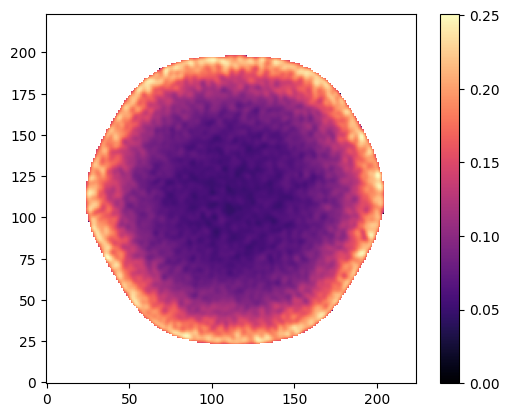

In [5]:
#inspect rms map
plt.imshow(rms.data, cmap='magma', origin='lower')
plt.colorbar()

In [6]:
#one can then produce different moment maps, using the velocity range where there is signal
#first define the range of channels you are going to use:
slab = cube_sc.spectral_slab(5.0*u.km/u.s, 7.0*u.km/u.s)

#make map of peak intensity
Tpeak = slab.max(axis=0)

#make moment 1 map
Mom1 = slab.moment1()

#make moment 0 map
Mom0 = slab.moment0()

This function (<function BaseSpectralCube.max at 0x13e147010>) requires loading the entire cube into memory and may therefore be slow.
All-NaN slice encountered
invalid value encountered in divide


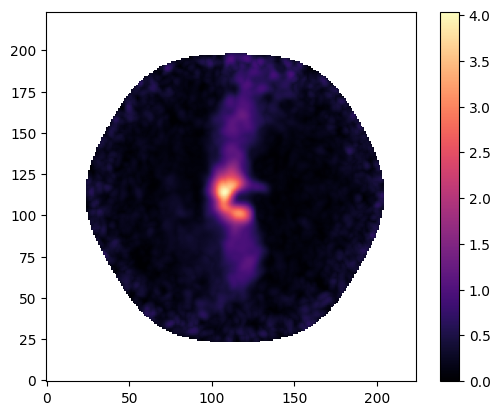

In [7]:
#inspect peak intensity map
plt.imshow(Tpeak.data, vmin=0, cmap='magma', origin='lower')
plt.colorbar()

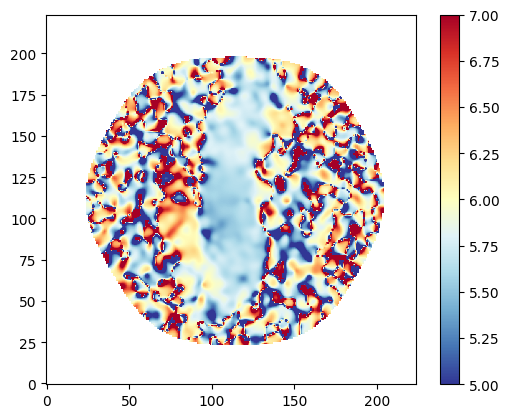

In [8]:
#inspect moment 1 map
plt.imshow(Mom1.data, vmin=5.0, vmax=7.0, cmap='RdYlBu_r', origin='lower')
plt.colorbar()

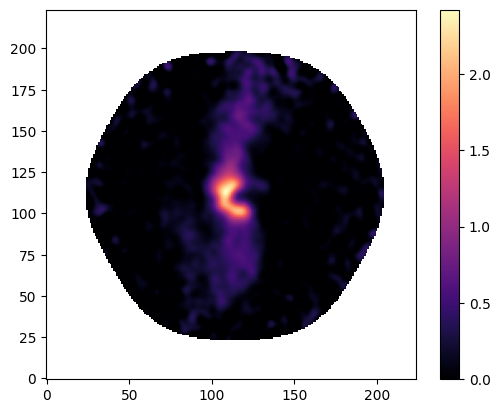

In [9]:
#inspect moment 0 map
plt.imshow(Mom0.data, vmin=0, cmap='magma', origin='lower')
plt.colorbar()

In [10]:
#ignore
#Tpeak_name = '../HOPS169_N2Dp_cube_smoothed_2as_rebinned_2_mom_peak.fits'
#Tpeak_data = fits.getdata(Tpeak_name, ext=0)
#Tpeak_im = Tpeak_data[0,:,:]
#rms_name = '../HOPS169_N2Dp_cube_smoothed_2as_rebinned_2_mom_stdev.fits'
#rms_data = fits.getdata(rms_name, ext=0)
#rms_im = rms_data[0,:,:]

In [11]:
#obtain signal-to-noise ratio (SNR) map, noise=rms, Tpeak=pico del espectro
peaksnr =  Tpeak/rms

divide by zero encountered in divide


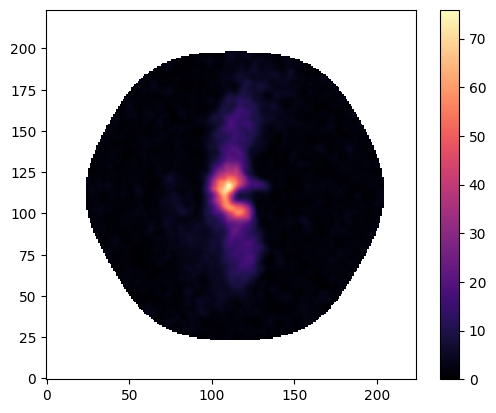

In [12]:
#inspect SNR map
plt.imshow(peaksnr.data, vmin=0, cmap='magma', origin='lower')
plt.colorbar()

In [13]:
#Make SNR mask, where we only include only pixels with SNR above snr_min in the mask, snr = signal to noise
snr_min = 5
planemask = (peaksnr > snr_min)

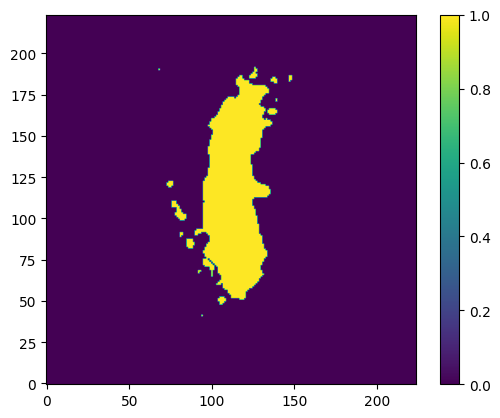

In [14]:
#inspect how mask looks
plt.imshow(planemask,origin='lower')
plt.colorbar()

In [15]:
peaksnr.header
from skimage.morphology import remove_small_objects,closing,disk,opening

In [16]:
planemask_ed = remove_small_objects(planemask, min_size=80)

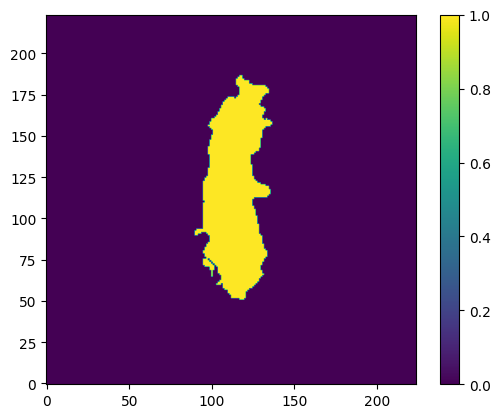

In [17]:
plt.imshow(planemask_ed,origin='lower')
plt.colorbar()

In [18]:
#ignore
#data_dir = '../HOPS169_N2Dp_smooth_rebin_'
#rms_file = data_dir + 'rms.fits'
#SNR_file = data_dir + 'SNR.fits'
#Tpeak_file = data_dir + 'Tpeak.fits'
#mask_file = data_dir + 'mask.fits'
#hd_cube=cube.header.copy()
#key_remove=['NAXIS3','CRPIX3','CDELT3','CUNIT3','CTYPE3','CRVAL3','SPECSYS']
#for key_i in key_remove:
#    hd_cube.remove(key_i)
#hd_cube['WCSAXES'] = 2
#fits.writeto(rms_file, rms_im, hd_cube, overwrite=True)
#fits.writeto(Tpeak_file, Tpeak_im, hd_cube, overwrite=True)
#fits.writeto(SNR_file, peaksnr, hd_cube, overwrite=True)
#fits.writeto(mask_file, planemask.astype(int), hd_cube, overwrite=True)

In [19]:
#tell pyspeckit kind of fit that you will do
cube.Registry.add_fitter('n2dp_vtau', pyspeckit.models.n2dp.n2dp_vtau_fitter,4)

In [20]:
#approximate pixel coordinates of maximum emission in cube:
xmax = 108; ymax = 114
#range of velocities you expect in velocity map. An estimate can be obtained from moment 1 map:
vmin = 5.0; vmax = 7.0

In [21]:
#guesses = Tpeak, tau, vel, width
#perform the fit
#this fits imposes that line is optically thin
cube.fiteach(fittype='n2dp_vtau',  guesses=[85.0, 0.1, 5.0, 0.15],
                 #verbose_level=1, 
                 signal_cut=snr_min,
                 limitedmin=[True, True, True, True],
                 limitedmax=[True, False, True, True],
                 minpars=[3.0, 0, vmin, 0.05],
                 maxpars=[100.0, 0, vmax, 1.0],
                 fixed=[False, True, False, False], 
                 use_neighbor_as_guess=True, 
                 start_from_point=(xmax, ymax),
                 errmap=rms.data, 
                 maskmap=planemask_ed)#, multicore=8)
# cube.write_fit(file_thin, overwrite=True)

Mean of empty slice


INFO: Fitting up to 3820 spectra [pyspeckit.cubes.SpectralCube]
INFO: Finished fit      1 of   3820 at ( 108, 114) s/n= 70.3. Elapsed time is 0.3 seconds.  %0 [pyspeckit.cubes.SpectralCube]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,400 [pyspeckit.spectrum.interactive]
INFO: Finished fit      1 of   3820 at ( 114, 108) s/n= 20.5. Elapsed time is 0.8 seconds.  %0 [pyspeckit.cubes.SpectralCube]
INFO: Finished fit      2 of   3820 at ( 113, 108) s/n= 26.1. Elapsed time is 0.9 seconds.  %0 [pyspeckit.cubes.SpectralCube]
INFO: Finished fit      3 of   3820 at ( 114, 107) s/n= 26.0. Elapsed time is 1.1 seconds.  %0 [pyspeckit.cubes.SpectralCube]
INFO: Finished fit      4 of   3820 at ( 114, 109) s/n= 18.4. Elapsed time is 1.3 seconds.  %0 [pyspeckit.cubes.SpectralCube]
INFO: Finished fit      5 of   3820 at ( 115, 108) s/n= 17.2. Elapsed time is 1.5 seconds.  %0 [pyspeckit.cubes.SpectralCube]
INFO: Finished fit      6 of   3820 at ( 115, 109) s/n= 13.5. Elapsed time is 1.7 s

In [22]:
#ignore
#write cube out with fit parameters
#cube.write_fit(file_thin, overwrite=True)

#cube.Registry.add_fitter('n2dp_vtau', pyspeckit.models.n2dp.n2dp_vtau_fitter, 4)

#cube.load_model_fit(file_thin, npars=4, npeaks=1, _temp_fit_loc=(xmax, ymax))

In [23]:
#make map of one of the fit parameters
cube.mapplot.plane = cube.parcube[2, :, :]

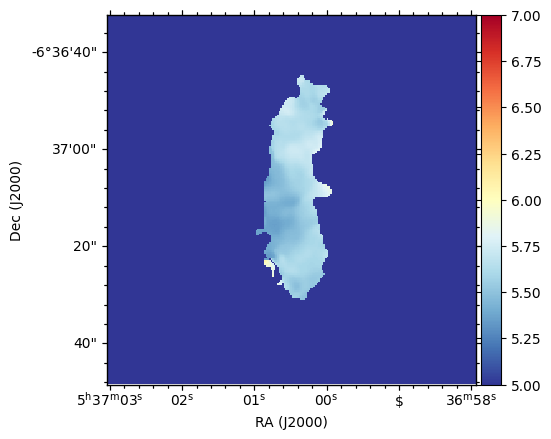

In [24]:
#inspect map
vmin_plot = 5.0; vmax_plot = 7.0
cube.mapplot(estimator=None, vmin=vmin_plot, vmax=vmax_plot,cmap='RdYlBu_r')

Text(0.5, 1.0, 'HOPS164 MIP Spectrum with Thin_SNR5_Fit')

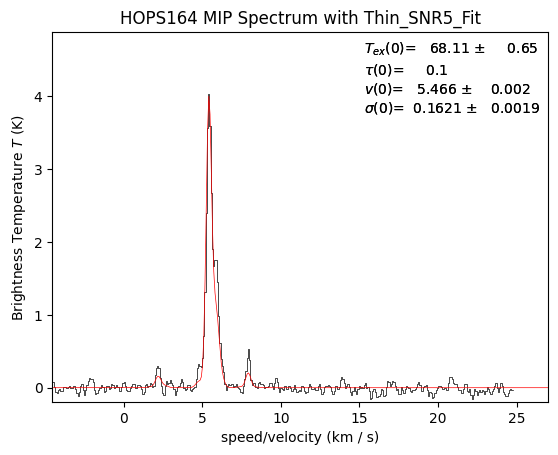

In [25]:
#check out fit in maximum intensity pixel
cube.plot_spectrum(xmax, ymax, plot_fit=True)
plt.title('HOPS164 MIP Spectrum with Thin_SNR5_Fit')

In [26]:
#write out parametes to a cube
data_dir = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/'
file_thick = data_dir + 'fit_thin_long_snr{0}.fits'.format(snr_min)
cube.write_fit(file_thick, overwrite=True)